# Imports

In [58]:
%load_ext autoreload
%autoreload 2
import gc
import os
import sys
import random
import wandb
sys.path.append('../utils')
sys.path.append('../data_utils')
sys.path.append('../models')
import numpy as np
import matplotlib.pyplot as plt
from ABC_dataset import get_item, ABCdataset, get_vdb_data_loader
import mesh_tools as mt
import fvdb_utils as fu
import model as fvdbModel
import igl
from meshplot import plot
import fvdb
import fvdb.nn as fvnn
import torch
import torch.nn as nn
from tqdm import tqdm
from skimage import measure

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Args

In [59]:
pos_enc_dim=10
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sdf_dir = '/data/workspaces/spanwar/dataset/ssu_data/ssu_processed_data/sdf_data_unit_circle_norm'
sdf_nmc_dir = '/data/workspaces/spanwar/dataset/nmc_data/groundtruth/gt_NMC'
ponq_data_dir = '/data/workspaces/spanwar/dataset/ponq_dataset/gt_Quadrics'

# Load Datasets

In [60]:
train_set_names = os.listdir(ponq_data_dir)[:150]

In [61]:
random.shuffle(train_set_names)
train_size = int(0.6 * len(train_set_names))
test_size = int(0.2 * len(train_set_names))
val_size = len(train_set_names) - train_size - test_size
train_names = train_set_names[:train_size]
val_names = train_set_names[train_size:train_size + val_size]
test_names = train_set_names[train_size + val_size:]

train_dataset = ABCdataset(ponq_data_dir, train_names)
val_dataset = ABCdataset(ponq_data_dir, val_names)
test_dataset = ABCdataset(ponq_data_dir, test_names, mode='test')

print(f'Number of samples in the dataset: {len(train_set_names)}')
print(f'Number of samples in the train set: {len(train_dataset)}')
print(f'Number of samples in the test set: {len(test_dataset)}')
print(f'Number of samples in the validation set: {len(val_dataset)}')

100%|██████████| 30/30 [00:00<00:00, 22545.98it/s]


Number of samples in the dataset: 150
Number of samples in the train set: 90
Number of samples in the test set: 30
Number of samples in the validation set: 30


In [62]:
# %reload_ext autoreload
train_data_loader = get_vdb_data_loader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
val_data_loader = get_vdb_data_loader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
test_data_loader = get_vdb_data_loader(test_dataset, batch_size=1, shuffle=False, num_workers=0, mode='test')

# Model

In [63]:
def positional_encoding(small_vdb, dim):
    '''helps the learning'''
    feat = small_vdb.jdata
    half_dim = dim // 2
    emb = torch.arange(
        start=0, end=half_dim, dtype=torch.float32, device=feat.device)
    emb = 2**emb * torch.pi
    emb = feat.float() * emb[None, :]
    new_feat = torch.cat([feat, emb.sin(), emb.cos()], dim=-1)
    return fvnn.VDBTensor(small_vdb.grid, small_vdb.grid.jagged_like(new_feat))

In [64]:
def vae_loss(recon_x, x, mu, logvar):
    # Reconstruction loss (e.g., MSE)
    recon_loss = (recon_x.jdata - x.jdata).pow(2).mean()  # Mean Squared Error
   
    # KL divergence
    logvar = torch.clamp(logvar, min=-10, max=10)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + 1e-3 * kld  # Adjust KLD weight as needed

In [65]:
model = fvdbModel.CNN_VAE(in_channels=pos_enc_dim+1, features=128, out_channels=1)
model = model.to(device)

In [66]:
# model summary and parameters
def print_model_summary(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params}")
    print(f"Trainable parameters: {trainable_params}")
print_model_summary(model)
# show model architecture
print(model)

Total parameters: 15416961
Trainable parameters: 15416961
CNN_VAE(
  (en1): SparseConv3d(11, 128, kernel_size=(7, 7, 7))
  (en1_bn): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (en1_act): SiLU(inplace=True)
  (en2): SparseConv3d(128, 128, kernel_size=(7, 7, 7), stride=(2, 2, 2))
  (en2_bn): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (en2_act): SiLU(inplace=True)
  (en3): SparseConv3d(128, 128, kernel_size=(5, 5, 5), stride=(2, 2, 2))
  (en3_bn): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (en3_act): SiLU(inplace=True)
  (en4): SparseConv3d(128, 128, kernel_size=(5, 5, 5), stride=(2, 2, 2))
  (en4_bn): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (en4_act): SiLU(inplace=True)
  (en5): SparseConv3d(128, 128, kernel_size=(5, 5, 5), stride=(2, 2, 2))
  (en5_bn): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (e

In [67]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-5)
criterion = nn.MSELoss()

# Model Training

In [68]:
# wandb.init(project="SSU", entity="sp_kumar", name="SSU_PONQ_DATA_VAE`", config={
#     "Discpription": "Implementing simple CNN VAE model from 32x32x32 (with positional encoding) to 32x32x32",
#     "batch_size": 1,
#     "learning_rate": 1e-3,
#     "epochs": 10,
#     "positional_encoding_dim": 10,
#     "model": "CNN_VAE",
#     "dataset": "PONQ Dataset",
#     "dataset_size": len(train_set_names),
#     "dataset_split": {
#         "train": len(train_dataset),
#         "val": len(val_dataset),
#         "test": len(test_dataset)
#     },
#     "model_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
#     "loss_function": "VAE loss",
#     "optimizer": "Adam",
#     "device": device
# })

In [69]:
def train(model, train_data_loader, val_data_loader, optimizer, criterion, epochs, device):
    history = []
    # saliency_labels = ['sdf'] + [f'pos_enc_{i}' for i in range(pos_enc_dim)]
    # saliency_feature = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        Loss = []
        
        model.train()
        for small_vdb, large_vdb in tqdm(train_data_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            small_vdb = positional_encoding(small_vdb, pos_enc_dim)
            # small_vdb.jdata.requires_grad_()
            large_vdb = large_vdb.to(device)
            
            optimizer.zero_grad()
            recon, mu, logvar = model(small_vdb)
            loss = vae_loss(recon, small_vdb, mu, logvar)

            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()

        # save saliency 
        # saliency_feature.append(small_vdb.jdata.grad.abs().mean(dim=0).cpu().numpy())
        
        avg_loss = epoch_loss / len(train_data_loader)
        Loss.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

        # Validation
        with torch.no_grad():
            
            model.eval()
            val_loss = 0
            
            for small_vdb, large_vdb in tqdm(val_data_loader, desc='Validation'):
                small_vdb = positional_encoding(small_vdb.to(device), pos_enc_dim)
                large_vdb = large_vdb.to(device)

                recon, mu, logvar = model(small_vdb)
                loss = vae_loss(recon, small_vdb, mu, logvar)
                
                val_loss += loss.item()
            
            avg_val_loss = val_loss / len(val_data_loader)
            print(f'Validation Loss: {avg_val_loss:.4f}')
        
        Loss.append(avg_val_loss)
        # wandb.log({
        # "train_loss": avg_loss,
        # "val_loss": avg_val_loss,
        # "epoch": epoch})

        history.append(Loss)

    return history

In [70]:
gc.collect()
torch.cuda.empty_cache()

In [71]:
history = train(model, 
                train_data_loader, 
                val_data_loader, 
                optimizer, 
                criterion, 
                epochs=10, 
                device=device)

Epoch 1/10: 100%|██████████| 90/90 [00:07<00:00, 12.71it/s]


Epoch 1/10, Loss: 2.1467


Validation: 100%|██████████| 30/30 [00:01<00:00, 19.66it/s]


Validation Loss: 1.9230


Epoch 2/10: 100%|██████████| 90/90 [00:06<00:00, 13.29it/s]


...

Validation Loss: 0.9017


Epoch 10/10: 100%|██████████| 90/90 [00:06<00:00, 12.94it/s]


Epoch 10/10, Loss: 0.7019


Validation: 100%|██████████| 30/30 [00:01<00:00, 19.12it/s]

Validation Loss: 0.8391


# Plot

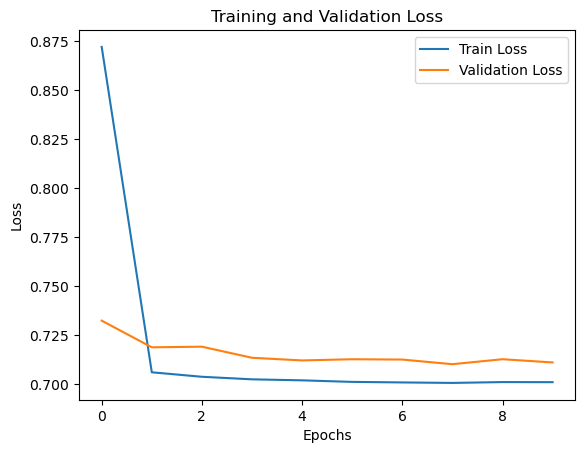

In [16]:
history = np.clip(history, 0, 10)
plt.plot(history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

In [17]:
# idx = random.randint(0, len(test_dataset)-1)
idx=0
small_sdf, large_sdf, mask, input, actual = test_dataset[idx]
input = positional_encoding(input, pos_enc_dim).to(device)
actual = actual.to(device)

# large grid from small VDBTensor
small_vdb, large_grid = fu.sdf_to_vdb(small_sdf, 
                                      None, 
                                      mask = mask, 
                                      size=33, mode='test')

pred, _, _ = model(input)

In [ ]:
def upload_plot_mesh_to_wandb(v, f, title):
    """Upload a mesh to wandb"""
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    # Plot the mesh using trisurf
    ax.plot_trisurf(v[:, 0], v[:, 1], v[:, 2], triangles=f, cmap='viridis', edgecolor='none', alpha=0.8)
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    
    # Log to wandb
    wandb.log({f'mesh_image: {title}': wandb.Image(fig)})
    plt.close(fig)

In [ ]:
v, f = fu.vdb_marching_cubes(small_vdb)
upload_plot_mesh_to_wandb(v, f, title='small SDF')
plot(v,f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-6.370246…

In [ ]:
v, f = fu.vdb_marching_cubes(pred)
upload_plot_mesh_to_wandb(v, f, title='predition')
plot(v, f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0195829…

In [21]:
# v, f = fu.vdb_marching_cubes(actual)
# plot(v, f)

In [34]:
wandb.finish()

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f634d199050>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7f6343a6eb10, raw_cell="wandb.finish()" store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bgin/user/spanwar/home/Documents/learn-fvdb/ssu/SSU/src/main/ssu_vae.ipynb#X31sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

BrokenPipeError: [Errno 32] Broken pipe

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f634d199050>> (for post_run_cell), with arguments args (<ExecutionResult object at 7f6340465650, execution_count=34 error_before_exec=None error_in_exec=[Errno 32] Broken pipe info=<ExecutionInfo object at 7f6343a6eb10, raw_cell="wandb.finish()" store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bgin/user/spanwar/home/Documents/learn-fvdb/ssu/SSU/src/main/ssu_vae.ipynb#X31sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe